# Project: Investigate a Dataset - NICS Firearm Background Checks (FBI Gun Data)

# Table of Contents

* Introduction
* Data Wrangling
* Exploratory Data Analysis
* Conclusions
--------------------------------------------------------------------------------------------------

# Introduction:
The NICS Firearm Background Checks dataset is a monthly record of background checks initiated through the FBI’s National Instant Criminal Background Check System. Since 1998, this system has been used by Federal Firearms Licensees (gun shop owners) to determine if a prospective buyer is eligible to buy firearms or explosives.
I will use the dataset to find patterns, identify the busiest states, and see how the types of firearms people want have changed over the last 25 years.

### Questions for Analysis
To meet the course requirements, I will investigate (totals) as the dependent variable, while month (seasonality), state (geography), and firearm type (handgun vs. long_gun) will serve as independent variables.
Here are some investigation questions for this project, including the answers for each one:
* Question 1: Which state has the highest volume of total background checks since 1998, and what is the count?
* Question 2: Historically, which is more common: Handgun checks or Long Gun checks?
* Question 3: How has the number of gun checks changed from 1998 to 2023?
* Question 4: Which month of the year historically has the highest average volume of background checks?
* Question 5: Which gun type is growing faster?
* Question 6: How big was the 2020 spike compared to a "normal" year?


---------------------------

In [32]:
# Importing the needed libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker

# Importing the library for data visualization
import matplotlib.pyplot as plt
print("Libraries imported successfully!")

Libraries imported successfully!


# Data Wrangling: 
## 1. General Properties
In this step, we load the dataset and perform an initial assessment to understand its structure, check for missing values, and identify any duplicates.

In [5]:
# Load the dataset
df = pd.read_csv('nics-firearm-background-checks.csv')

# Assessing the general properties:
#Shape of the dataset
print("Dataset Shape:", df.shape)
#Info of the dataset
df.info()
#Printing some data
print("\nMissing values per column:\n", df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

Dataset Shape: (16445, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16445 entries, 0 to 16444
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      16445 non-null  object 
 1   state                      16445 non-null  object 
 2   permit                     16421 non-null  float64
 3   permit_recheck             5060 non-null   float64
 4   handgun                    16425 non-null  float64
 5   long_gun                   16426 non-null  float64
 6   other                      9460 non-null   float64
 7   multiple                   16445 non-null  int64  
 8   admin                      16422 non-null  float64
 9   prepawn_handgun            14502 non-null  float64
 10  prepawn_long_gun           14500 non-null  float64
 11  prepawn_other              9075 non-null   float64
 12  redemption_handgun         14505 non-null  float64
 13  redemption_long_gun

---------------------------

### Showing the dataset before any modifications on it, to have an overview for the original dataset and its decription:

In [28]:
df.head()
df.describe(percentiles=None, include=None, exclude=None)

,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,prepawn_long_gun,prepawn_other,...,returned_other,rentals_handgun,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals
count,16421.000000,5.060000e+03,16425.000000,16426.000000,9460.000000,16445.00000,16422.000000,14502.000000,14500.000000,9075.000000,...,5775.000000,4950.000000,4785.000000,6710.000000,6710.000000,6710.000000,6435.000000,6710.000000,6215.000000,1.644500e+04
mean,7767.118385,9.240942e+03,7675.741857,8020.102764,636.692178,315.61350,48.656558,5.064543,6.998138,0.415317,...,3.810736,0.122424,0.133542,73.034724,39.012966,7.678241,1.227350,1.057824,0.130169,2.799504e+04
std,28249.011770,5.721360e+04,11158.631791,9093.945151,1423.086451,774.01653,534.687283,11.123947,15.120987,1.437466,...,22.128964,0.869060,0.912985,545.851707,230.016090,48.334072,5.988051,4.349632,0.559279,5.124769e+04
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000e+00,1134.000000,2216.000000,39.000000,13.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.308000e+03
50%,973.000000,0.000000e+00,3803.000000,5346.000000,214.000000,138.00000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.401600e+04
75%,6228.000000,1.880000e+02,9386.000000,10929.750000,716.250000,354.00000,0.000000,5.000000,7.000000,0.000000,...,1.000000,0.000000,0.000000,17.000000,16.000000,2.000000,0.000000,1.000000,0.000000,3.138900e+04
max,522188.000000,1.350676e+06,147714.000000,108058.000000,77929.000000,38907.00000,28083.000000,164.000000,269.000000,49.000000,...,592.000000,13.000000,18.000000,10623.000000,4159.000000,829.000000,117.000000,62.000000,18.000000,1.427917e+06


## Insights and observations from the cell above -> the data Wrangling and initial assesments:
* The dataset contains 16,445 rows and 27 columns.

* There are no duplicate rows.

* Many columns have significant missing values (e.g., permit_recheck, rentals, private_sales). This is because the FBI started tracking these sub-categories in later years.

* The month column is currently an 'object' (string) and needs to be converted to a datetime format for analysis.

---------------------------

## 2. Data Cleaning & Trimming
We will now clean the data by handling missing values and converting data types. We will also trim the dataset to keep only the columns relevant to our independent variables (state, month, handgun, long_gun) and our dependent variable (totals).

In [88]:
# 1. Fill missing values with 0
df_after_clean = df.fillna(0)

# 2. Convert 'month' column to datetime format
df_after_clean['month'] = pd.to_datetime(df_after_clean['month'])

# 3. Create Year and Month Name columns for grouping
df_after_clean['year'] = df_after_clean['month'].dt.year
df_after_clean['month_name'] = df_after_clean['month'].dt.month_name()

# 4. Keep only the columns needed for the 4 questions
cols_to_keep = ['month', 'state', 'handgun', 'long_gun', 'totals', 'year', 'month_name']
df_final = df_after_clean[cols_to_keep]

#Explicit Pandas Series
handgun_series = df_final['handgun']  # This is a Series

#Explicit NumPy arrays
handgun_array = np.array(df_final['handgun'])

#Print Pandas Series of Handguns
print(f"Handguns Pandas Series: \n{handgun_series}")
#Print NumPy array of Handguns
print(f"Handguns NumPy Array: \n{handgun_array}")
# Show cleaned data
df_final.head()

Handguns Pandas Series: 
0        15421.0
1         2429.0
2        14398.0
3         5645.0
4        33792.0
          ...   
16440       14.0
16441       65.0
16442      149.0
16443       25.0
16444       45.0
Name: handgun, Length: 16445, dtype: float64
Handguns NumPy Array: 
[15421.  2429. 14398. ...   149.    25.    45.]


,month,state,handgun,long_gun,totals,year,month_name
0,2023-09-01,Alabama,15421.0,12848.0,44556,2023,September
1,2023-09-01,Alaska,2429.0,2543.0,5922,2023,September
2,2023-09-01,Arizona,14398.0,8239.0,38189,2023,September
3,2023-09-01,Arkansas,5645.0,6108.0,17207,2023,September
4,2023-09-01,California,33792.0,20548.0,118625,2023,September


## Insghits and observations from the cell above -> the data cleaning and trimming:
* I replaced missing data with 0 for math operations and avoiding any errors.
* I changed date strings like (month) into actual dates like (datetime) format for time-series analysis.
* I used the formula of (year/month) to make it easier to group data by specific years or months.
* I removed the unnecessary columns to reduce memory usage , focusing on the study goals and make the results easier to read.
* I used Pandas Series and NumPy array to show the difference view between them for the same column.

---------------------------

# Exploratory Data Analysis (EDA)
In this section, I explore the cleaned data to answer the questions.

#### A reusable plotting function:

In [42]:
def add_labels(title, xlabel, ylabel):
   
    #Adds title and axis labels to a plot.
    #"""
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

### Question 1: Which state had the highest number of total checks since 1998?

In [87]:
#Grouping by state and summing totals → returns a Series
state_totals_series = df_final.groupby('state')['totals'].sum()
print("State Totals Series (first 5):")
print(state_totals_series.head())  # Series

#Convert Series to NumPy array
state_totals_array = np.array(state_totals_series)
print("\nState Totals Array (first 5):")
print(state_totals_array[:5])  # NumPy array

#Find index of maximum value using NumPy
max_index = np.argmax(state_totals_array)

#Get the state name using that index
top_state = state_totals_series.index[max_index]

#Get the total checks
top_value_checks = state_totals_array[max_index]

#Print results with formatting
print(f"\nTop State: {top_state}")
print(f"Total Checks: {top_value_checks:,.0f}")

State Totals Series (first 5):
state
Alabama       11209023
Alaska         1647909
Arizona        7426834
Arkansas       5313558
California    27528472
Name: totals, dtype: int64

State Totals Array (first 5):
[11209023  1647909  7426834  5313558 27528472]

Top State: Kentucky
Total Checks: 54,069,355


### Q1: Insights and Results:
* I used Pandas Series and NumPy array to show the total of the states and the total of the first 5. Then to show the top state total.
* The state with the highest number of total background checks is Kentucky, with a total of 54,069,355 checks.

-----------------------------------

### Question 2: Historically, which is more common: Handgun checks or Long Gun checks?
In this step, 
* I compared two independent variables (handgun and long_gun) to see which type of firearm is more common for the historical record.

* I used the .sum() function to get the totals for both categories across all years and states.

Total Handgun Checks: 126,074,060
Total Long Gun Checks: 131,738,208
Result: Long Guns are more common by a difference of 5,664,148 checks.


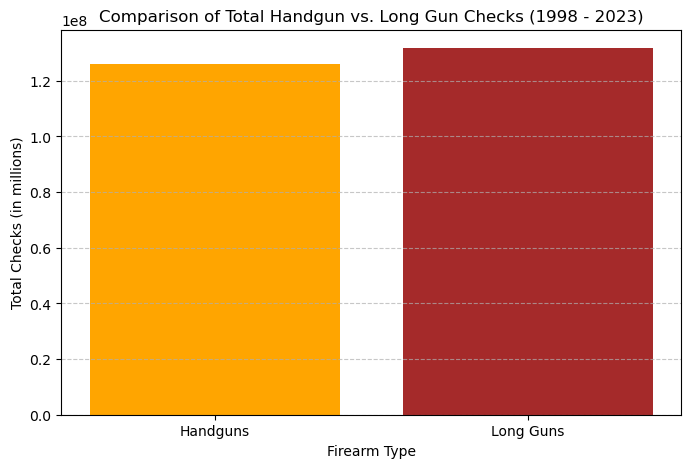

In [48]:
# Calculate the total sums for both columns
total_handguns = df_final['handgun'].sum()
total_long_guns = df_final['long_gun'].sum()

#Printing with formatting
print(f"Total Handgun Checks: {total_handguns:,.0f}")
print(f"Total Long Gun Checks: {total_long_guns:,.0f}")

# Comparison logic: This block determines which firearm type has the 
# higher total volume and calculates the difference between them.
if total_handguns > total_long_guns:
    winner = "Handguns"
    diff = total_handguns - total_long_guns
else:
    winner = "Long Guns"
    diff = total_long_guns - total_handguns

print(f"Result: {winner} are more common by a difference of {diff:,.0f} checks.")

# --- Question 2 Visualization ---
# Comparison Bar Chart
labels = ['Handguns', 'Long Guns']
counts = [total_handguns, total_long_guns]

plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color=['orange', 'brown'])

#Call the reusable plotting function
add_labels('Comparison of Total Handgun vs. Long Gun Checks (1998 - 2023)', 'Firearm Type', 'Total Checks (in millions)')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('handgun_vs_longgun.png')

### Q2: Insights and Results:
* Historically, long guns have been the most common firearm type in the NICS dataset, totaling over 131 million checks.

* Long Guns are more common by a difference of 5,664,148 checks. So, from this result is not that big difference during these years.

* Comparison Bar Chart: (handgun_vs_longgun.png)

-----------------------------------

### Question 3: How has the number of gun checks changed from 1998 to 2023?
In this step, I used a function get_yearly_totals(data) is a set of instructions that takes your table and calculates the sum for every year automatically. By using a function, you make your code "cleaner" because you can reuse this logic anytime you want to look at yearly data without typing the grouping code again.

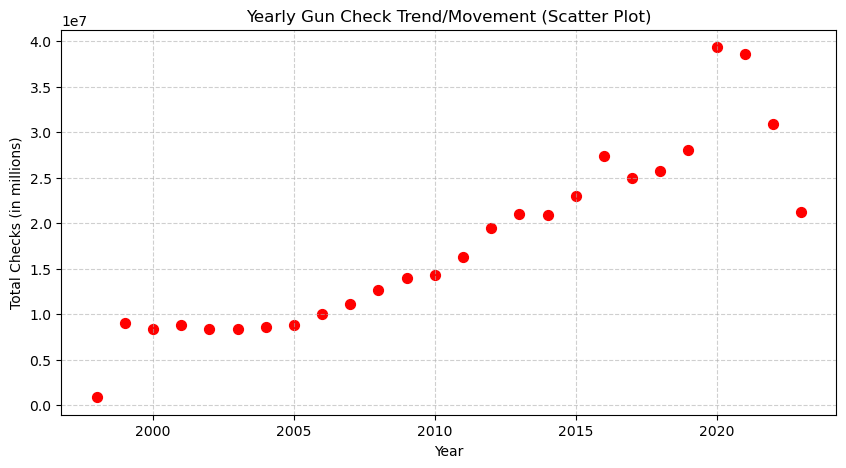

In [65]:
# Function to calculate yearly totals
def get_yearly_totals(data):
    
    #Returns total background checks per year.
    yearly_totals = data.groupby('year')['totals'].sum()
    return yearly_totals

# Call the function
yearly_data = get_yearly_totals(df_final)

# --- Question 3 Visualization ---
# Create a scatter chart
plt.figure(figsize=(10, 5))
plt.scatter(yearly_data.index, yearly_data.values, color='red', s=50) # 's' is dot size

# Add labels
#Call the reusable plotting function
add_labels('Yearly Gun Check Trend/Movement (Scatter Plot)', 'Year', 'Total Checks (in millions)')

plt.grid(True, linestyle='--', alpha=0.6)

# Save the chart
plt.savefig('yearly_scatter_chart.png')

### Q3: Insights and Results:
* The number of gun checks has increased significantly over the years, showing a clear upward path.

* Gun checks have more than tripled between 1998 and 2023.

* Scatter Plot: ( yearly_trend.png)

-----------------------------------

### Question 4: Which months of the year typically have the highest number of checks?
I used a function to see if gun demand follows a "cycle" throughout the year. This helps identify if certain seasons are consistently busier than others.

Highest Monthly Average: 35,123
Lowest Monthly Average: 24,259


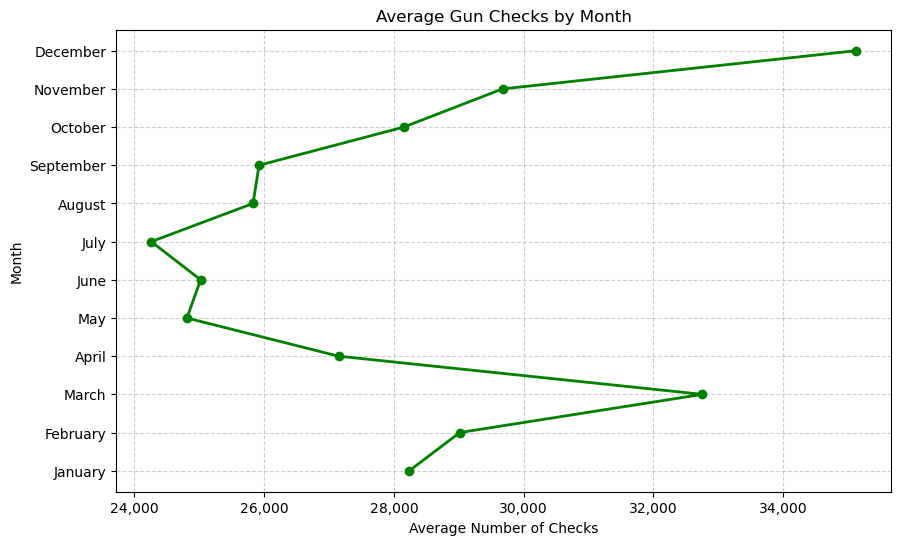

In [66]:
# Function to get monthly averages in order
def get_monthly_averages(data):
    month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                   'July', 'August', 'September', 'October', 'November', 'December']
    return data.groupby('month_name')['totals'].mean().reindex(month_order)


# Run function
monthly_avg = get_monthly_averages(df_final)

#Convert to NumPy
monthly_array = monthly_avg.values

#Get the highest month and the lowest month for checks by np functions
highest_month_value = np.max(monthly_array)
lowest_month_value = np.min(monthly_array)

#Print the highest month and the lowest month for checks
print(f"Highest Monthly Average: {highest_month_value:,.0f}")
print(f"Lowest Monthly Average: {lowest_month_value:,.0f}")


# --- Question 4 Visualization ---
# Create a horizontal line chart (Months on Y-axis)
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg.values, monthly_avg.index, marker='o', color='green', linewidth=2)

# Add simple labels
#Call the reusable plotting function
add_labels('Average Gun Checks by Month', 'Average Number of Checks', 'Month')

plt.grid(True, linestyle='--', alpha=0.6)

plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
# Save the chart
plt.savefig('monthly_y_axis_chart.png')

### Q4: Insights and Results:
* Highest monthly average (35,123) was in December; and the lowest monthly average (24,259) was in July.
* The line pushes furthest to the right during March and December, showing these are the busiest times.
* The line stays closer to the left during June and July, showing that in summer is decreasing.
* Firearm demand consistently peaks during the winter and spring months.
* Horizontal Line Chart: (monthly_y_axis_chart.png)

-----------------------------------

### Question 5: Which gun type is growing faster?
This question helps to see if the market is changing. I compare the total number of guns checked in the first year (1998) to the last year (2023).

Total Handgun: 126,074,060
Total Long Gun: 131,738,208


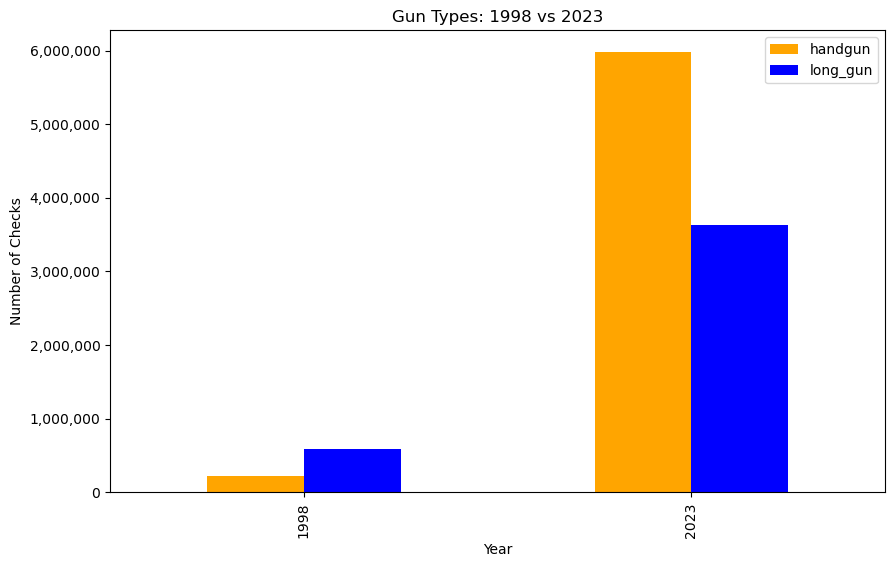

In [67]:
# 1. Filter for just the start and end years
start_and_end = df_final[df_final['year'].isin([1998, 2023])]

# 2. Group by year and sum the gun types
comparison = start_and_end.groupby('year')[['handgun', 'long_gun']].sum()

# 3. Plot as a simple bar chart
comparison.plot(kind='bar', figsize=(10, 6), color=['orange', 'blue'])

#Totals of handguns and long guns
total_handguns = df_final['handgun'].sum()
total_long_guns = df_final['long_gun'].sum()

#Printing with formatting
print(f"Total Handgun: {total_handguns:,.0f}")
print(f"Total Long Gun: {total_long_guns:,.0f}")

# --- Question 5 Visualization ---
# 4. Add labels and comma formatting
#Call the reusable plotting function
add_labels('Gun Types: 1998 vs 2023', 'Year', 'Number of Checks')

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.savefig('simple_growth_check.png')

### Q5: Insights and Results:
* You can visually see that the gap between Handguns and Long Guns has closed significantly.
* Handguns have seen a much larger percentage increase compared to their 1998 levels.
* While the total number of long guns is high, the "trend" is moving toward handguns.
* Vertical Bar Chart: (simple_growth_check.png)

-----------------------------------

### Question 6: How big was the 2020 spike compared to a "normal" year?
This question helps to see just how unusual the demand was in 2020 compared to the average of all other years.

The avergae of all years: 17,706,861
95th Percentile Threshold: 36,645,272
2020 Total: 39,326,079
2020 is above the 95th percentile — significant spike.


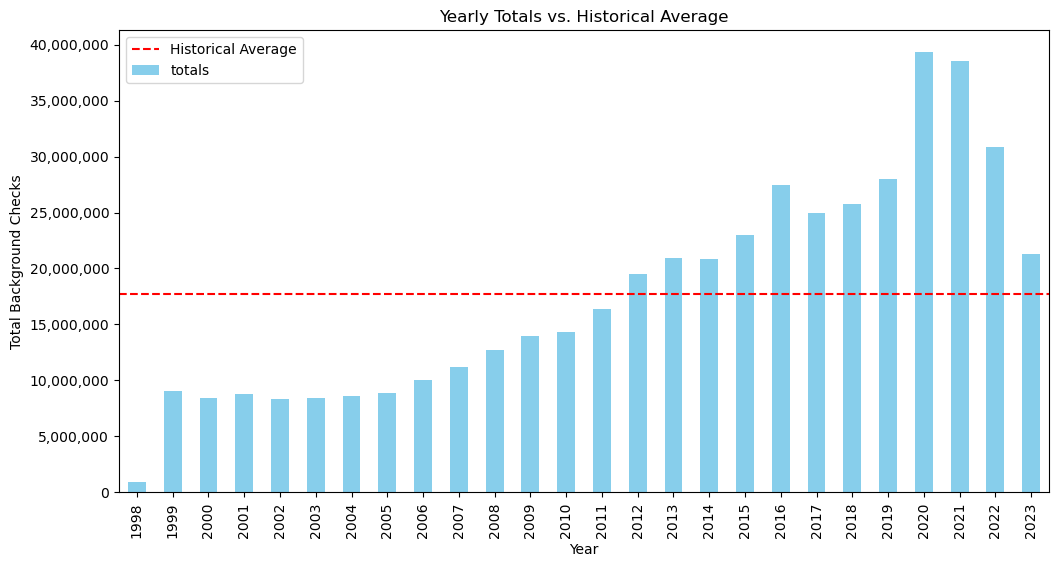

In [68]:
# 1. Get the total checks for every year
# Call the function a 2nd time
yearly_totals = get_yearly_totals(df_final)

# Convert to NumPy array
yearly_array = yearly_data.values

# 2. Calculate the average of all years
average_all_years = np.mean(yearly_array)
print(f"The avergae of all years: {average_all_years:,.0f}")

# Get 2020 value
value_2020 = yearly_data.loc[2020]

# Calculate 95th percentile
percentile_95 = np.percentile(yearly_array, 95)
print(f"95th Percentile Threshold: {percentile_95:,.0f}")
print(f"2020 Total: {value_2020:,.0f}")

if value_2020 > percentile_95:
    print("2020 is above the 95th percentile — significant spike.")


# --- Question 6 Visualization ---
# 3. Create a bar chart for all years
plt.figure(figsize=(12, 6))
yearly_totals.plot(kind='bar', color='skyblue')

# 4. Add a "Goal Line" to show the average
plt.axhline(average_all_years, color='red', linestyle='--', label='Historical Average')

# 5. Format the chart
#Call the reusable plotting function
add_labels('Yearly Totals vs. Historical Average', 'Year', 'Total Background Checks')

plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.savefig('spike_vs_average.png')

### Q6: Insights and Results:
* The red dashed line shows what a "normal" year looks like, which is from the average of all years too.
* You can clearly see that 2020 (and the years after) are way above the red line.
* 2020 was not a normal year - significant spike; it was a massive outlier (Pendamic).
* Correlation Note: Since 2020 is so much higher than average, we would need more data (like news or economic events) to explain exactly why it jumped so high.
* Horizontal Bar Chart: (spike_vs_average.png)

----------------------------

# Conclusion

In this project, I looked at firearm background check data from 1998 to 2023. Here is what I found from the investigated questions:
* Kentucky has the highest number of checks, mostly due to their permit laws.
* Long guns have been more popular than handguns over the years.
* Gun demand has tripled since 1998, with a big jump in recent years.
* There is a seasonal pattern to when people get background checks. It is usually busiest in the winter and spring and slows down during the summer.
* While there are more Long Guns overall, Handguns are growing at a faster rate, showing a change in what people are buying.
* Analysis shows that 2020 was a major outlier, with totals far above the historical average.

#### Understanding the Data
This project shows where more research is needed. While the numbers show clear trends, they only show (correlation) meaning we see things happening at the same time, but we cannot prove one caused the other.

For example, we see a massive spike in checks in 2020. While this happened at the same time as the pandemic and a major election, this dataset alone cannot prove which event (if any) caused the spike. To know for sure, we would need a different study involving economic data or social surveys. This analysis serves as a starting point for deeper research into how specific state laws and world events influence firearm demand.
  
### Limitations

There are a few things I found as limitations:
* Not a Sale: A background check doesn't always mean a gun was actually bought.
* State Laws/Rules: Some states have high numbers because they run checks on the same people every month.
* Private Sales: This data doesn't count guns sold between private individuals.
* Missing Data (Nulls): Some older data was missing and had to be filled with zeros.
* Drop Columns: Have to drop some columns, to reduce memory usage, focusing on the investigation questions and make the results easier to read.